In [331]:
import numpy as np
import matplotlib.pyplot as plt  
from collections import Counter
from sklearn.tree import DecisionTreeClassifier
import pandas as pd 

# Questão 01

### Funções auxiliares

In [332]:
class StandardScaler:
    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0) + 1e-9  

    def transform(self, X):
        return (X - self.mean) / self.std

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [333]:
class StratifiedKFold:
    def __init__(self, n_splits=10, shuffle=True, random_state=None):
        self.n_splits = n_splits
        self.shuffle = shuffle
        self.random_state = random_state

    def split(self, X, y):
        np.random.seed(self.random_state)

        classes = np.unique(y)
        class_indices = {}

        for c in classes:
            idx = np.where(y == c)[0]
            if self.shuffle:
                np.random.shuffle(idx)
            class_indices[c] = idx

        class_folds = {}
        for c, idx in class_indices.items():
            class_folds[c] = np.array_split(idx, self.n_splits)

        for i in range(self.n_splits):
            test_idx = []
            train_idx = []

            for c in classes:
                test_idx.extend(class_folds[c][i])
                for j in range(self.n_splits):
                    if j != i:
                        train_idx.extend(class_folds[c][j])

            yield np.array(train_idx), np.array(test_idx)

In [334]:
kc2 = np.loadtxt("kc2.csv", delimiter=",", skiprows=1)

In [335]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

In [336]:
def mahalanobis_distance(a, b, VI):
    diff = a - b
    return np.sqrt(np.dot(np.dot(diff.T, VI), diff))

In [337]:
def confusion_matrix_elements(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    
    return TP, TN, FP, FN

In [338]:
def accuracy(y_true, y_pred):
    TP, TN, FP, FN = confusion_matrix_elements(y_true, y_pred)
    return (TP + TN) / (TP + TN + FP + FN)

In [339]:
def precision(y_true, y_pred):
    TP, TN, FP, FN = confusion_matrix_elements(y_true, y_pred)
    if (TP + FP) == 0:
        return 0
    return TP / (TP + FP)

In [340]:
def recall(y_true, y_pred):
    TP, TN, FP, FN = confusion_matrix_elements(y_true, y_pred)
    if (TP + FN) == 0:
        return 0
    return TP / (TP + FN)

In [341]:
def f1_score(y_true, y_pred):
    p = precision(y_true, y_pred)
    r = recall(y_true, y_pred)
    
    if (p + r) == 0:
        return 0
    return 2 * (p * r) / (p + r)

In [342]:
X = kc2[:, :21]

y = kc2[:, 21]
y = y.astype(int)

### Letra A

In [343]:
class KNN:
    def __init__(self, k=3, distance='euclidean'):
        self.k = k
        self.distance = distance
    
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        
        if self.distance == 'mahalanobis':
            cov_matrix = np.cov(X.T)
            self.VI = np.linalg.pinv(cov_matrix)
    
    def _distance(self, a, b):
        if self.distance == 'euclidean':
            return euclidean_distance(a, b)
        elif self.distance == 'mahalanobis':
            return mahalanobis_distance(a, b, self.VI)
    
    def predict(self, X):
        predictions = []
        
        for x in X:
            distances = []
            
            for x_train in self.X_train:
                dist = self._distance(x, x_train)
                distances.append(dist)
            
            k_indices = np.argsort(distances)[:self.k]
            k_labels = self.y_train[k_indices]
            
            most_common = Counter(k_labels).most_common(1)
            predictions.append(most_common[0][0])
        
        return np.array(predictions)

### Letra B

In [344]:
def evaluate_model(model, X, y, kf):
    accs, precs, recs, f1s = [], [], [], []
    
    for train_idx, test_idx in kf.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        accs.append(accuracy(y_test, y_pred))
        precs.append(precision(y_test, y_pred))
        recs.append(recall(y_test, y_pred))
        f1s.append(f1_score(y_test, y_pred))
    
    return {
        "accuracy_mean": np.mean(accs),
        "accuracy_std": np.std(accs),
        "precision_mean": np.mean(precs),
        "precision_std": np.std(precs),
        "recall_mean": np.mean(recs),
        "recall_std": np.std(recs),
        "f1_mean": np.mean(f1s),
        "f1_std": np.std(f1s),
    }

In [345]:
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results = {}

In [346]:
configs = [
    ("KNN_k1_euclidean", KNN(k=1, distance='euclidean')),
    ("KNN_k5_euclidean", KNN(k=5, distance='euclidean')),
    ("KNN_k1_mahalanobis", KNN(k=1, distance='mahalanobis')),
    ("KNN_k5_mahalanobis", KNN(k=5, distance='mahalanobis')),
]

In [347]:
for name, model in configs:
    print(f"Rodando: {name}")
    results[name] = evaluate_model(model, X, y, kf)

Rodando: KNN_k1_euclidean
Rodando: KNN_k5_euclidean
Rodando: KNN_k1_mahalanobis
Rodando: KNN_k5_mahalanobis


In [348]:
tree_configs = [
    ("DecisionTree_gini", DecisionTreeClassifier(criterion='gini', random_state=42)),
    ("DecisionTree_entropy", DecisionTreeClassifier(criterion='entropy', random_state=42)),
]

In [349]:
for name, model in tree_configs:
    print(f"Rodando: {name}")
    results[name] = evaluate_model(model, X, y, kf)

Rodando: DecisionTree_gini
Rodando: DecisionTree_entropy


In [350]:
df_results = pd.DataFrame(results).T
print(df_results.round(4))

                      accuracy_mean  accuracy_std  precision_mean  \
KNN_k1_euclidean             0.7626        0.0779          0.7949   
KNN_k5_euclidean             0.8030        0.0652          0.8173   
KNN_k1_mahalanobis           0.7146        0.1050          0.7789   
KNN_k5_mahalanobis           0.7426        0.0563          0.8261   
DecisionTree_gini            0.7383        0.0909          0.7714   
DecisionTree_entropy         0.7099        0.0581          0.7536   

                      precision_std  recall_mean  recall_std  f1_mean  f1_std  
KNN_k1_euclidean             0.1110       0.7309      0.1323   0.7524  0.0885  
KNN_k5_euclidean             0.1127       0.8145      0.0683   0.8086  0.0499  
KNN_k1_mahalanobis           0.1741       0.6564      0.1191   0.6996  0.1005  
KNN_k5_mahalanobis           0.1129       0.6455      0.1146   0.7121  0.0696  
DecisionTree_gini            0.1342       0.7382      0.1017   0.7424  0.0716  
DecisionTree_entropy         0.1214 

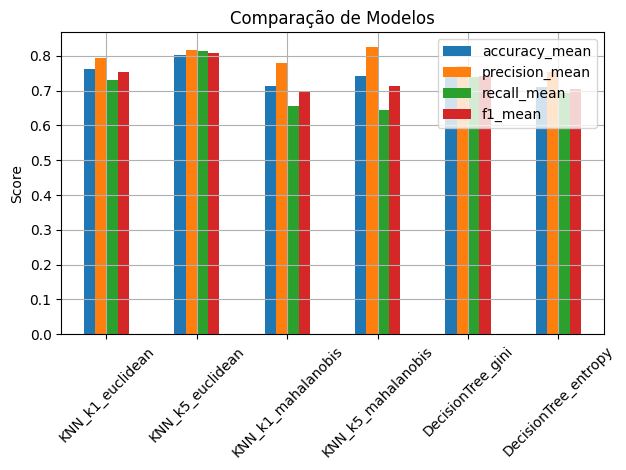

In [351]:
df_plot = df_results[[
    "accuracy_mean",
    "precision_mean",
    "recall_mean",
    "f1_mean"
]]

df_plot.plot(kind="bar")

plt.title("Comparação de Modelos")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

In [352]:
df_results.sort_values(by="f1_mean", ascending=False)

,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
KNN_k5_euclidean,0.803030,0.065176,0.817258,0.112734,0.814545,0.068297,0.808581,0.049933
KNN_k1_euclidean,0.762554,0.077906,0.794870,0.110968,0.730909,0.132253,0.752400,0.088462
DecisionTree_gini,0.738268,0.090936,0.771354,0.134203,0.738182,0.101704,0.742350,0.071642
KNN_k5_mahalanobis,0.742554,0.056316,0.826136,0.112950,0.645455,0.114560,0.712061,0.069599
DecisionTree_entropy,0.709870,0.058120,0.753649,0.121390,0.691818,0.108212,0.704682,0.043251
KNN_k1_mahalanobis,0.714632,0.105014,0.778919,0.174121,0.656364,0.119074,0.699639,0.100503


In [353]:
best_model = df_results["f1_mean"].idxmax()
print("Melhor modelo:", best_model)

Melhor modelo: KNN_k5_euclidean
